# Bloque 4 — Analítica clásica con base de datos
### Curso: Digitalización en Acuicultura

---

En este notebook aprenderemos a usar una **base de datos real** para almacenar y consultar datos de calidad del agua.

Trabajaremos con mediciones reales de una zona de producción acuícola (2015-2019):
- **Parámetros**: Oxígeno, Turbidez, Clorofila, Transparencia
- **Estaciones**: 12 puntos de muestreo (SP_1 a SP_12)
- **Profundidades**: Fondo y Superficie
- **Periodo**: marzo 2015 – noviembre 2019

El flujo del notebook es:
1. Crear una base de datos SQLite y cargar los datos
2. Hacer consultas SQL para responder preguntas concretas
3. Visualizar los resultados

> `sqlite3` viene incluido en Python — no hace falta instalar nada extra.


## Sección 0 — Librerías

Solo necesitamos `sqlite3` (base de datos), `pandas` (leer el Excel y mostrar resultados) y `matplotlib` (gráficos).

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## Sección 1 — Crear la base de datos y cargar los datos

Primero leemos el fichero Excel con pandas.  
Luego creamos una base de datos SQLite (un fichero `.db` local) y volcamos todos los registros en una tabla llamada `mediciones`.

A partir de aquí **ya no usamos el Excel** — todas las consultas van contra la base de datos.


In [5]:
# Leer el Excel
df = pd.read_excel("PVA_AGUA_SP_15_19.xlsx")

# Renombrar columnas para que sean más cómodas en SQL
df = df.rename(columns={
    "Fecha":       "fecha",
    "Estación":    "estacion",
    "Prof.":       "profundidad",
    "Cordenada X": "coord_x",
    "Cordenada Y": "coord_y",
    "Parámetro":   "parametro",
    "Unidades":    "unidades",
    "Valor":       "valor",
})

# Convertir fecha a string para SQLite
df["fecha"] = df["fecha"].astype(str)

print(f"Registros cargados desde Excel: {len(df)}")
print()
print(df.head(5).to_string())


Registros cargados desde Excel: 1249

        fecha estacion profundidad  coord_x  coord_y  parametro unidades  valor
0  2015-03-16     SP_1       Fondo   705535  4189814  Clorofila    mg/m3   1.02
1  2015-03-16     SP_1  Superficie   705535  4189814  Clorofila    mg/m3   0.96
2  2015-03-16     SP_2       Fondo   704785  4189802  Clorofila    mg/m3   1.12
3  2015-03-16     SP_2  Superficie   704785  4189802  Clorofila    mg/m3   0.72
4  2015-03-16     SP_3       Fondo   704019  4189814  Clorofila    mg/m3   1.08


In [6]:
# Crear la base de datos SQLite
conn = sqlite3.connect("calidad_agua.db")

# Crear tabla
conn.execute("""
    CREATE TABLE IF NOT EXISTS mediciones (
        id          INTEGER PRIMARY KEY AUTOINCREMENT,
        fecha       TEXT,
        estacion    TEXT,
        profundidad TEXT,
        coord_x     REAL,
        coord_y     REAL,
        parametro   TEXT,
        unidades    TEXT,
        valor       REAL
    )
""")

# Vaciar por si ya existía de una ejecución anterior
conn.execute("DELETE FROM mediciones")

# Insertar todos los registros
df.to_sql("mediciones", conn, if_exists="replace", index=False)
conn.commit()

# Verificar
n = conn.execute("SELECT COUNT(*) FROM mediciones").fetchone()[0]
print(f"Registros insertados en la base de datos: {n}")


Registros insertados en la base de datos: 1249


In [7]:
# Exploración básica: ¿qué hay en la base de datos?
print("=== Parámetros disponibles ===")
for row in conn.execute("SELECT DISTINCT parametro, unidades FROM mediciones ORDER BY parametro"):
    print(f"  {row[0]:<20} ({row[1]})")

print()
print("=== Estaciones de muestreo ===")
estaciones = [r[0] for r in conn.execute("SELECT DISTINCT estacion FROM mediciones ORDER BY estacion")]
print("  " + ", ".join(estaciones))

print()
print("=== Rango temporal ===")
row = conn.execute("SELECT MIN(fecha), MAX(fecha) FROM mediciones").fetchone()
print(f"  Desde {row[0]}  hasta  {row[1]}")


=== Parámetros disponibles ===
  Clorofila            ( mg/m3)
  Clorofila            (mg/m3)
  Clorofila            (mg/m³)
  Oxígeno              (mg/l)
  Oxígeno              (%)
  Oxígeno              (mg/L)
  Transparencia        (m)
  Turbidez             (NTU)

=== Estaciones de muestreo ===
  SP_1, SP_10, SP_11, SP_12, SP_2, SP_3, SP_4, SP_5, SP_6, SP_7, SP_8, SP_9

=== Rango temporal ===
  Desde 2015-03-16  hasta  2019-11-29


## Sección 2 — Estadísticos descriptivos globales

La primera pregunta es siempre la más básica: ¿cuál es el comportamiento general de cada parámetro?

Con una sola consulta SQL obtenemos la media, el mínimo y el máximo de cada variable.


In [8]:
query = """
    SELECT
        parametro,
        unidades,
        ROUND(AVG(valor), 3)  AS media,
        ROUND(MIN(valor), 3)  AS minimo,
        ROUND(MAX(valor), 3)  AS maximo,
        COUNT(*)              AS n_registros
    FROM mediciones
    GROUP BY parametro
    ORDER BY parametro
"""

resumen = pd.read_sql(query, conn)
print(resumen.to_string(index=False))


    parametro unidades  media  minimo  maximo  n_registros
    Clorofila    mg/m3  0.925    0.00   7.764          408
      Oxígeno     mg/l  7.664    6.05  97.300          409
Transparencia        m 14.017   12.10  16.300           24
     Turbidez      NTU  0.797    0.00   7.075          408


## Sección 3 — ¿Varía la calidad del agua entre estaciones?

Calculamos la **media de oxígeno por estación** para detectar si hay zonas sistemáticamente peor oxigenadas.

Esta es exactamente la consulta que un técnico de granja haría para decidir dónde reforzar la aireación.


In [9]:
query = """
    SELECT
        estacion,
        ROUND(AVG(valor), 3) AS media_o2
    FROM mediciones
    WHERE parametro = 'Oxígeno'
    GROUP BY estacion
    ORDER BY media_o2 ASC
"""

o2_por_estacion = pd.read_sql(query, conn)
print(o2_por_estacion.to_string(index=False))


estacion  media_o2
    SP_6     7.102
    SP_2     7.194
    SP_7     7.226
    SP_8     7.231
    SP_5     7.244
   SP_10     7.249
    SP_3     7.272
   SP_11     7.280
   SP_12     7.286
    SP_1     7.318
    SP_4     9.625
    SP_9     9.880


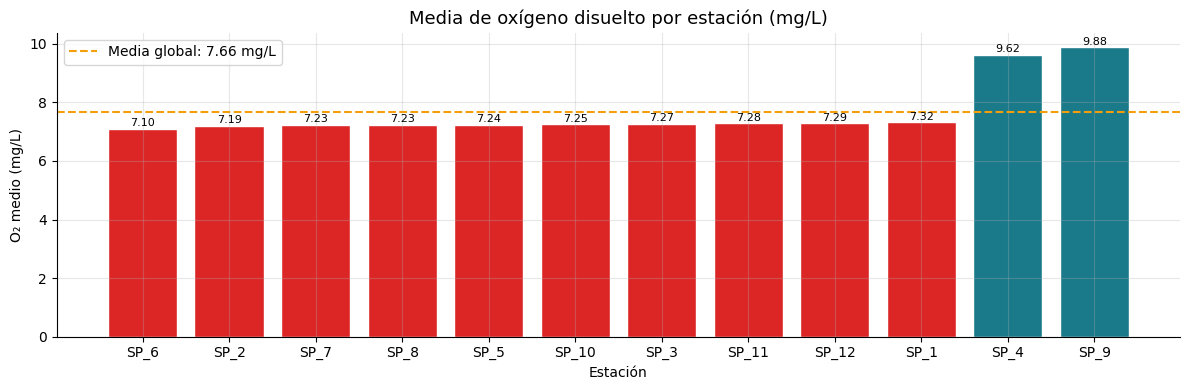

In [10]:
fig, ax = plt.subplots()
colores = ['#DC2626' if v < o2_por_estacion['media_o2'].mean() else '#1A7A8A'
           for v in o2_por_estacion['media_o2']]
bars = ax.bar(o2_por_estacion['estacion'], o2_por_estacion['media_o2'], color=colores, edgecolor='white')
ax.axhline(o2_por_estacion['media_o2'].mean(), color='#F59E0B', linestyle='--', linewidth=1.5,
           label=f"Media global: {o2_por_estacion['media_o2'].mean():.2f} mg/L")
ax.set_title('Media de oxígeno disuelto por estación (mg/L)', fontsize=13)
ax.set_ylabel('O₂ medio (mg/L)')
ax.set_xlabel('Estación')
ax.legend()
# Etiquetas sobre las barras
for bar, val in zip(bars, o2_por_estacion['media_o2']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


## Sección 4 — ¿Hay variación a lo largo del tiempo?

Agrupamos las mediciones por año para ver si la calidad del agua ha mejorado, empeorado o se mantiene estable entre 2015 y 2019.

Extraemos el año directamente en SQL con la función `SUBSTR`.


In [11]:
query = """
    SELECT
        SUBSTR(fecha, 1, 4)  AS anio,
        parametro,
        ROUND(AVG(valor), 3) AS media
    FROM mediciones
    GROUP BY anio, parametro
    ORDER BY anio, parametro
"""

evolucion = pd.read_sql(query, conn)
print(evolucion.to_string(index=False))


anio     parametro  media
2015     Clorofila  0.728
2015       Oxígeno  8.096
2015      Turbidez  0.771
2016     Clorofila  1.307
2016       Oxígeno  7.894
2016      Turbidez  1.200
2017     Clorofila  1.305
2017       Oxígeno  6.751
2017      Turbidez  0.743
2018     Clorofila  0.716
2018       Oxígeno  8.666
2018 Transparencia 14.017
2018      Turbidez  0.301
2019     Clorofila  0.420
2019       Oxígeno  7.225
2019      Turbidez  0.951


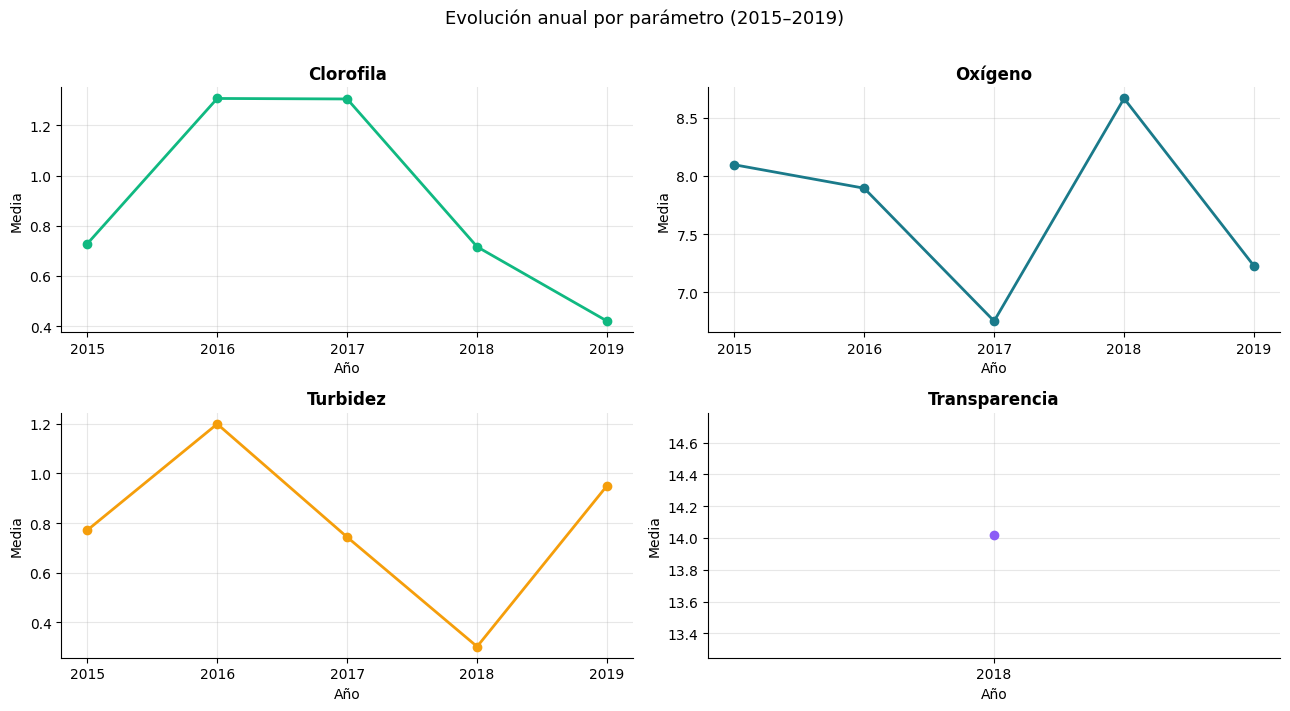

In [12]:
parametros = evolucion['parametro'].unique()
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

colores_param = {
    'Oxígeno':       '#1A7A8A',
    'Turbidez':      '#F59E0B',
    'Clorofila':     '#10B981',
    'Transparencia': '#8B5CF6',
}

for ax, param in zip(axes, parametros):
    datos = evolucion[evolucion['parametro'] == param]
    color = colores_param.get(param, '#64748B')
    ax.plot(datos['anio'], datos['media'], marker='o', color=color, linewidth=2, markersize=6)
    ax.set_title(param, fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Media')
    ax.set_xlabel('Año')

plt.suptitle('Evolución anual por parámetro (2015–2019)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Sección 5 — ¿Cuándo y dónde se registraron los valores más extremos?

Identificamos las 10 mediciones con **menor oxígeno** registrado.  
En una instalación real, estos serían los eventos prioritarios a investigar.


In [13]:
query = """
    SELECT
        fecha,
        estacion,
        profundidad,
        ROUND(valor, 3) AS o2_mgL
    FROM mediciones
    WHERE parametro = 'Oxígeno'
    ORDER BY valor ASC
    LIMIT 10
"""

extremos = pd.read_sql(query, conn)
print("=== 10 registros con menor oxígeno disuelto ===")
print()
print(extremos.to_string(index=False))


=== 10 registros con menor oxígeno disuelto ===

     fecha estacion profundidad  o2_mgL
2018-05-15     SP_3       Fondo    6.05
2018-05-15     SP_6       Fondo    6.09
2018-05-15     SP_9       Fondo    6.10
2017-08-31     SP_3       Fondo    6.12
2018-05-15     SP_2       Fondo    6.13
2019-05-27    SP_10  Superficie    6.13
2017-08-31     SP_5       Fondo    6.14
2017-08-31     SP_7       Fondo    6.14
2017-08-31    SP_11       Fondo    6.14
2017-08-31     SP_6       Fondo    6.15


In [14]:
# Y los 10 con mayor turbidez
query = """
    SELECT
        fecha,
        estacion,
        profundidad,
        ROUND(valor, 3) AS turbidez_NTU
    FROM mediciones
    WHERE parametro = 'Turbidez'
    ORDER BY valor DESC
    LIMIT 10
"""

turbidez_extrema = pd.read_sql(query, conn)
print("=== 10 registros con mayor turbidez ===")
print()
print(turbidez_extrema.to_string(index=False))


=== 10 registros con mayor turbidez ===

     fecha estacion profundidad  turbidez_NTU
2019-08-28     SP_1  Superficie         7.075
2019-08-28     SP_8  Superficie         6.226
2019-05-27     SP_4  Superficie         4.500
2016-03-15     SP_6  Superficie         4.400
2016-03-15     SP_8  Superficie         3.500
2016-08-29     SP_6       Fondo         3.400
2016-06-01     SP_6       Fondo         3.100
2016-11-24     SP_3       Fondo         2.900
2016-11-24     SP_4       Fondo         2.700
2019-05-27     SP_7  Superficie         2.600


## Sección 6 — ¿Hay diferencias entre fondo y superficie?

El dataset tiene lecturas en fondo y superficie para cada punto. La estratificación de la columna de agua puede ser un indicador de problemas de mezcla o de consumo de oxígeno en el fondo.

Usamos un `CASE WHEN` dentro del `AVG` para pivotar los datos directamente en SQL.


In [15]:
query = """
    SELECT
        estacion,
        ROUND(AVG(CASE WHEN profundidad = 'Fondo'      THEN valor END), 3) AS media_fondo,
        ROUND(AVG(CASE WHEN profundidad = 'Superficie' THEN valor END), 3) AS media_superficie,
        ROUND(
            AVG(CASE WHEN profundidad = 'Superficie' THEN valor END) -
            AVG(CASE WHEN profundidad = 'Fondo'      THEN valor END),
        3) AS diferencia_sup_fondo
    FROM mediciones
    WHERE parametro = 'Oxígeno'
    GROUP BY estacion
    ORDER BY diferencia_sup_fondo DESC
"""

estratificacion = pd.read_sql(query, conn)
print(estratificacion.to_string(index=False))


estacion  media_fondo  media_superficie  diferencia_sup_fondo
    SP_9        7.144            12.616                 5.473
    SP_4        7.258            11.860                 4.602
    SP_6        6.982             7.221                 0.239
    SP_7        7.156             7.296                 0.140
    SP_2        7.124             7.264                 0.139
    SP_3        7.211             7.333                 0.122
   SP_12        7.235             7.336                 0.101
   SP_11        7.247             7.313                 0.066
   SP_10        7.235             7.264                 0.029
    SP_8        7.235             7.226                -0.009
    SP_5        7.259             7.228                -0.031
    SP_1        7.354             7.282                -0.072


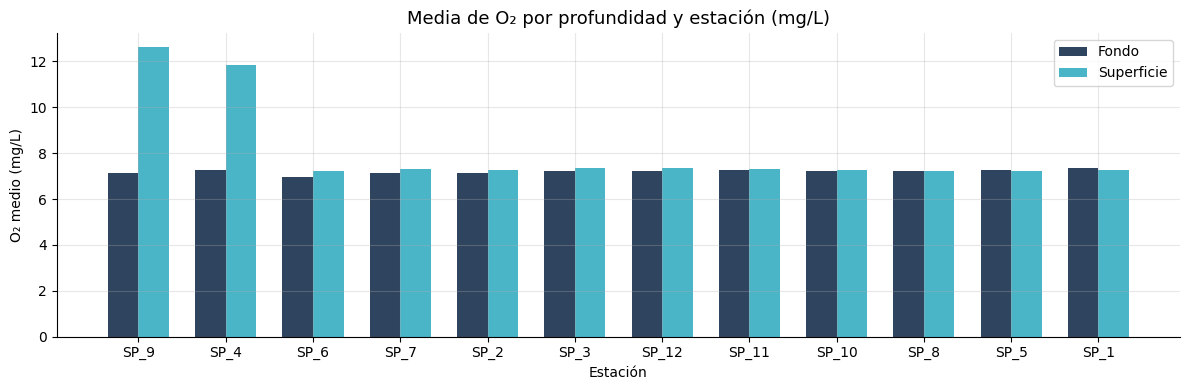

In [16]:
x = range(len(estratificacion))
width = 0.35

fig, ax = plt.subplots()
b1 = ax.bar([i - width/2 for i in x], estratificacion['media_fondo'],
            width, label='Fondo', color='#0A2342', alpha=0.85)
b2 = ax.bar([i + width/2 for i in x], estratificacion['media_superficie'],
            width, label='Superficie', color='#2BA8BF', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(estratificacion['estacion'])
ax.set_title('Media de O₂ por profundidad y estación (mg/L)', fontsize=13)
ax.set_ylabel('O₂ medio (mg/L)')
ax.set_xlabel('Estación')
ax.legend()
plt.tight_layout()
plt.show()


---

## Resumen

| Consulta | Lo que hemos aprendido |
|---|---|
| **Estadísticos globales** | Rango y comportamiento típico de cada parámetro |
| **Media por estación** | Qué zonas tienen peor oxigenación de forma sistemática |
| **Evolución anual** | Si la calidad del agua mejora, empeora o se mantiene |
| **Valores extremos** | Cuándo y dónde ocurrieron los eventos más críticos |
| **Fondo vs. superficie** | Si hay estratificación que indique problemas de mezcla |

> Todas estas preguntas se han respondido con **SQL puro** ejecutado sobre una base de datos local.  
> En un entorno de producción real, la base de datos estaría en un servidor y las consultas serían exactamente las mismas.


In [17]:
# Cerrar la conexión cuando terminemos
conn.close()
print("Conexión cerrada.")


Conexión cerrada.
